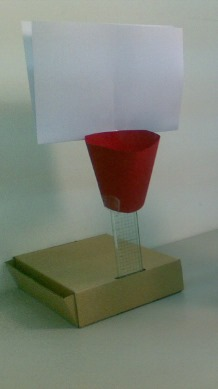

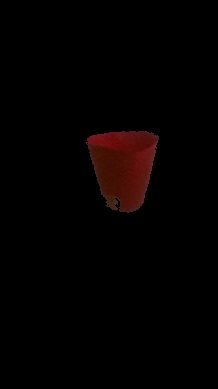

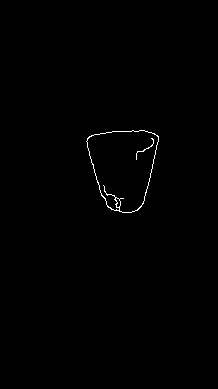

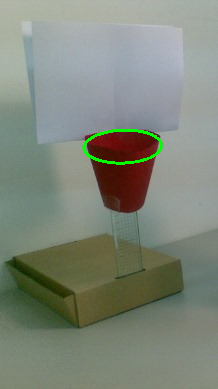

In [23]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow
redbasket=cv2.imread('img111.jpeg')
cv2_imshow(redbasket)
redrgb=cv2.cvtColor(redbasket,cv2.COLOR_BGR2RGB)
lower_red1 = np.array([50, 0, 0])
upper_red1 = np.array([255,45, 45])
mask1 = cv2.inRange(redrgb, lower_red1, upper_red1)
res = cv2.bitwise_and(redbasket,redbasket, mask= mask1)
cv2_imshow(res)
gray = cv2.cvtColor(res, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (7,7), 0)
edges = cv2.Canny(blur, 5, 40)
cv2_imshow(edges)
contours,_= cv2.findContours(edges, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)
cnt = max(contours, key=cv2.contourArea)
if len(contours) >0:
    y_coords = cnt[:,0,1]
    y_min = np.min(y_coords)
    top_points = cnt[y_coords < y_min + 30]
    if len(top_points) >= 5:
        ellipse = cv2.fitEllipse(top_points)
        output = redbasket
        cv2.ellipse(output, ellipse, (0,255,0), 2)
        cv2_imshow(output)